In [74]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, parent_dir)

In [75]:
from probts.data.data_utils.data_scaler import Scaler

from probts.model.forecaster import LinearForecaster, NaiveForecaster
from probts.model.forecast_module import ProbTSForecastModule
from probts.data import ProbTSDataModule, DataManager, ProbTSBatchData
from probts.utils import find_best_epoch
from lightning import Trainer
from pytorch_lightning.loggers import CSVLogger
import torch
import matplotlib.pyplot as plt

In [114]:
class BinaryQuantizer(Scaler):
    def __init__(self, num_bins=100, min_val=-5.0, max_val=5.0):
        self.num_bins = num_bins
        self.min_val = min_val
        self.max_val = max_val
        self.bin_values_ = torch.linspace(self.min_val, self.max_val, self.num_bins)

    def fit(self, values):
        self.min_val = values.min()
        self.max_val = values.max()
        self.bin_values_ = torch.linspace(self.min_val, self.max_val, self.num_bins)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)
    
    def transform(self, values):
        bin_thresholds = self.bin_values_.reshape(1, 1, -1)
        return (values >= bin_thresholds).long()

    def inverse_transform(self, values):
        reversed_bin = torch.flip(values, dims=(-1,))
        idx_first_one_reversed = reversed_bin.argmax(axis=-1)[..., None]
        idx_last_one = self.num_bins - 1 - idx_first_one_reversed
        reconstructed = self.bin_values_[idx_last_one]
        return reconstructed

In [76]:
data_manager = DataManager(
    dataset='tourism_monthly', 
    path='../datasets', 
    context_length=12, 
    prediction_length=12,
)

Loading Short-term Dataset: tourism_monthly


Download tourism_monthly_dataset.zip:: 200kB [00:01, 161kB/s]
creating json files: 100%|███████████████████████████████████████████████████████| 366/366 [00:00<00:00, 261074.02it/s]

No validation set is used.


In [161]:
class CustomDataManager(DataManager):
    def _configure_scaler(self, scaler_type: str):
        """Configure the scaler."""
        if scaler_type == "standard":
            return StandardScaler(var_specific=self.var_specific_norm)
        elif scaler_type == "temporal":
            return TemporalScaler()
        elif scaler_type == "binary":
            return BinaryQuantizer()
        return IdentityScaler()

In [77]:
data_module = ProbTSDataModule(
    data_manager=data_manager,
    batch_size=32,
    test_batch_size=32,
    num_workers=0,
)
test_dataloader = data_module.test_dataloader()
train_dataloader = data_module.train_dataloader()
val_dataloader = data_module.val_dataloader()

In [78]:
for test_batch in test_dataloader:
    break

In [117]:
batch_data = ProbTSBatchData(test_batch, 'cpu')
batch_data.past_target_cdf.shape

torch.Size([32, 24, 1])

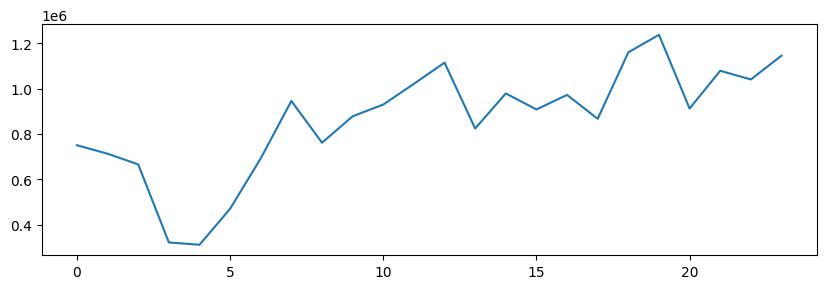

In [151]:
plt.figure(figsize=(10,3))
plt.plot(batch_data.past_target_cdf[13, :, 0].t())
plt.show()

In [152]:
scaler = BinaryQuantizer()
scaler.fit(batch_data.past_target_cdf)
transformed = scaler.transform(batch_data.past_target_cdf)
transformed.shape

torch.Size([32, 24, 100])

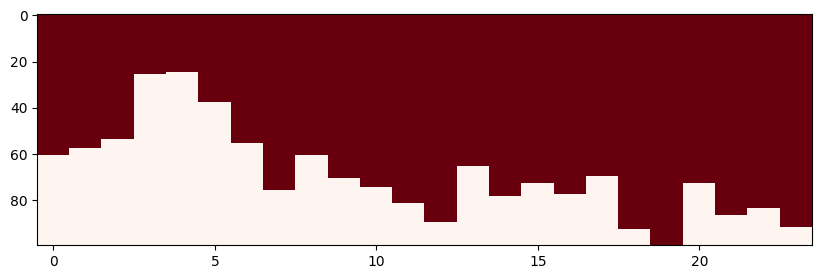

In [158]:
plt.figure(figsize=(10,3))
plt.imshow(transformed[13].T, aspect='auto', interpolation='none', cmap='Reds')
plt.show()

In [159]:
reconstructed = scaler.inverse_transform(transformed)
reconstructed.shape

torch.Size([32, 24, 1])

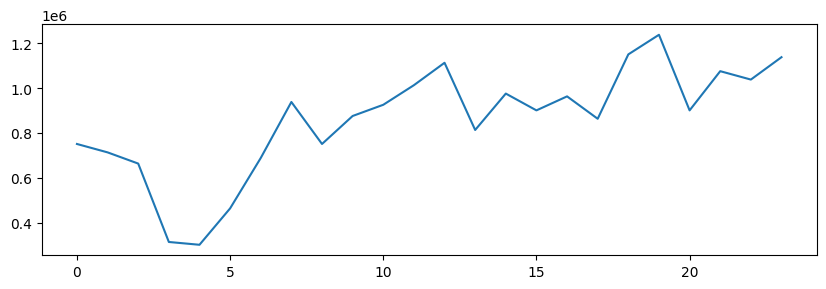

In [160]:
plt.figure(figsize=(10,3))
plt.plot(reconstructed[13, :, 0].t())
plt.show()

In [162]:
data_manager = CustomDataManager(
    dataset='tourism_monthly', 
    path='../datasets', 
    context_length=12, 
    prediction_length=12,
    scaler="binary",
)

Loading Short-term Dataset: tourism_monthly


Download tourism_monthly_dataset.zip:: 200kB [00:01, 181kB/s]
creating json files: 100%|███████████████████████████████████████████████████████| 366/366 [00:00<00:00, 277698.13it/s]

No validation set is used.


In [163]:
data_module = ProbTSDataModule(
    data_manager=data_manager,
    batch_size=32,
    test_batch_size=32,
    num_workers=0,
)
test_dataloader = data_module.test_dataloader()
train_dataloader = data_module.train_dataloader()
val_dataloader = data_module.val_dataloader()

In [164]:
for test_batch in test_dataloader:
    break

In [165]:
batch_data = ProbTSBatchData(test_batch, 'cpu')
batch_data.past_target_cdf.shape

torch.Size([32, 24, 1])